#### Analisis exploratorio de las variables seleccionadas como base para los centros urbanos seleccionados.
Este script analiza la relación entre PM2.5 y múltiples variables ambientales para una estación de monitoreo.
El objetivo es:
- Explorar correlaciones entre variables
- Identificar relaciones fuertes o redundantes
- Evaluar multicolinealidad mediante VIF
Esto permite seleccionar predictores más robustos para modelos de calidad de aire.

In [1]:
# Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
print("librerias ok")

librerias ok


### Carga de datos
- Dataset independiente por centro urbano almacenado en formato .csv
- Registros diarios por esta estaciones de monitoreo de PM2.5.
- Todos los centros urbanos parten de las mismas variables base ( n = 17)

In [2]:
# Estacion
estacion = "BA"
data = pd.read_csv(f"D:/Josefina/Proyectos/ProyectoChile/{estacion}/proceed/merge_tot/{estacion}_merge_comp.csv")
#data.info() #Devuelve información número de filas, número de columnas, índices, tipo de objeto de cada columna
#--- Fromato date
data["date"] = data["date"].apply(lambda x: datetime.strptime(x,"%Y-%m-%d"))
# Seteamos con index a la columna
data.set_index('date', inplace = True)
# Columnas
data.columns


Index(['Unnamed: 0', 'X', 'ID', 'estacion', 'PM25', 'PM25_hora', 'AOD_055',
       'ndvi', 'BCSMASS_dia', 'DUSMASS_dia', 'DUSMASS25_dia', 'OCSMASS_dia',
       'SO2SMASS_dia', 'SO4SMASS_dia', 'SSSMASS_dia', 'SSSMASS25_dia',
       'blh_mean', 'blh_min', 'blh_max', 'blh_sd', 'sp_mean', 'sp_min',
       'sp_max', 'sp_sd', 'd2m_mean', 'd2m_min', 'd2m_max', 'd2m_sd',
       't2m_mean', 't2m_min', 't2m_max', 't2m_sd', 'v10_mean', 'v10_min',
       'v10_max', 'v10_sd', 'u10_mean', 'u10_min', 'u10_max', 'u10_sd',
       'tp_mean', 'tp_min', 'tp_max', 'tp_sd', 'DEM', 'dayWeek'],
      dtype='object')

Al momento de procesar cada una de las variables tambien se obtuvo valores minimos, maximos, desviacion estandar, y otras metricas por eso en el dataset original hay muchas mas variables. Pero finalmente se consideraron las medidas de cada registro.

In [3]:
# Nos quedamos solo con algunas columnas
data_subt = data[['PM25', 'AOD_055', 'ndvi', 'BCSMASS_dia',  'DUSMASS_dia', 'OCSMASS_dia', 'SO2SMASS_dia','SO4SMASS_dia', 'SSSMASS_dia', 'blh_mean',  'sp_mean', 'd2m_mean', 't2m_mean',  'v10_mean', 'u10_mean','tp_mean','DEM','dayWeek']]
#Cambiamos nombre de las columnas
data_subt.columns = ['PM2.5', 'AOD550', 'NDVI', 'BCSMASS', 'DUSMASS', 'OCSMASS', 'SO2SMASS', 'SO4SMASS', 'SSSMASS','blh', 'sp', 'd2m', 't2m', 'v10', 'u10','tp','DEM','dayWeek']

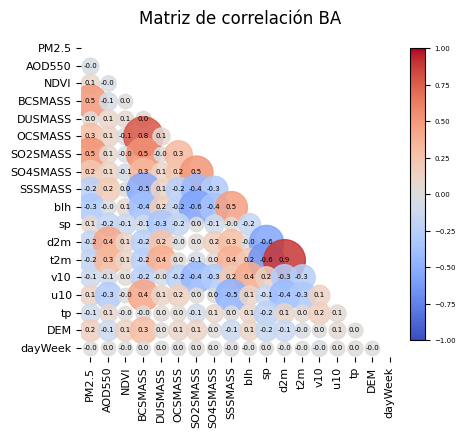

In [8]:
######### Plot para una mejor visualizacion
corr = data_subt.corr()
# Crear figura
fig, ax = plt.subplots(figsize=(5, 5))
labels = corr.columns
n = len(labels)
# Tamaño de los círculos
max_circle_size = 1000
min_circle_size = 100
# Colormap
cmap = plt.cm.coolwarm
# Dibujar mitad inferior
for i in range(n):
    for j in range(n):
        if i > j:
            val = corr.iloc[i, j]
            color = cmap((val + 1) / 2)
            size = np.abs(val) * (max_circle_size - min_circle_size) + min_circle_size
            ax.scatter(j, i, s=size, color=color, alpha=0.85)
            ax.text(j, i, f"{val:.1f}", ha='center', va='center', fontsize=5, color='black')
# Etiquetas
ax.set_xticks(np.arange(n))
ax.set_yticks(np.arange(n))
ax.set_xticklabels(labels, rotation=90, fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
# Ajustes visuales
ax.set_xlim(-0.5, n - 0.5)
ax.set_ylim(-0.9, n - 0.5)
ax.invert_yaxis()
ax.set_aspect('equal')
# Ocultar bordes
for spine in ax.spines.values():
    spine.set_visible(False)
# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-1, vmax=1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.7, pad=0.03)
cbar.ax.tick_params(labelsize=5)
# Título
plt.title(f"Matriz de correlación {estacion}", fontsize=12)
plt.tight_layout(pad=1.5)
plt.show()

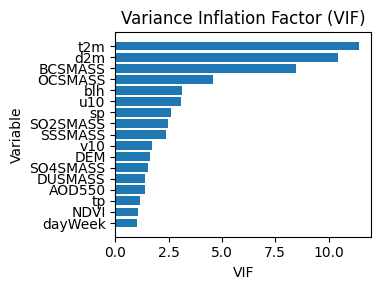

In [ ]:
#Analisis del Factor de Inflación de la Varianza (VIF)
variables = ['AOD550', 'NDVI', 'BCSMASS', 'DUSMASS', 'OCSMASS', 'SO2SMASS', 'SO4SMASS', 'SSSMASS','blh', 'sp', 'd2m', 't2m', 'v10', 'u10','tp','DEM','dayWeek']
## Setear variables
y = data_subt["PM2.5"]
X = data_subt[variables]
X_vif = X.dropna().copy()
# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vif)
vif_df = pd.DataFrame()
vif_df["Variable"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_scaled, i)for i in range(X_scaled.shape[1])]
vif_df_sorted = vif_df.sort_values("VIF", ascending=False)
##Plot
plt.figure(figsize=(4, 3))
plt.barh(vif_df_sorted["Variable"],  vif_df_sorted["VIF"])
plt.xlabel("VIF")
plt.ylabel("Variable")
plt.title("Variance Inflation Factor (VIF)")
plt.gca().invert_yaxis()  # mayor VIF arriba
plt.tight_layout()
plt.show()

En resumen, el análisis de correlación y VIF permitió seleccionar las variables más relevantes para cada sitio, evitando redundancias y asegurando que los modelos incorporen información complementaria, que permita mejorar la capacidad de predicción y generalización